# Gradient-Boosted Tree Baseline Comparison (CatBoost)

Benchmarks the neural FM-MLP against CatBoost on the same data: `model_dataset_{train,val,test}.parquet` from `02_Feature_Engineering.ipynb` (post survivorship-bias fix). CatBoost doesn't do the neural net's joint multi-task thing (one shared backbone, two heads) — so this trains two separate single-task models, a churn classifier and an LTV regressor, and compares each against its corresponding neural single-task ceiling: Exp-1 (churn-only) and Exp-2 (LTV-only) from `04_Training_Baselines.ipynb`.

Categorical columns (`city_enc`, `gender_enc`, `registered_via_enc`, `payment_method_id_enc`) are passed to CatBoost as native categoricals (`cat_features=...`), not as raw integers — CatBoost fits its own ordered target-statistic encoding internally, which is a fairer treatment than feeding it the label-encoded integers as if they were ordinal.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import average_precision_score, mean_absolute_error, r2_score, roc_auc_score

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

train_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_train.parquet"))
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
FEATURE_COLS = CAT_COLS + NUM_COLS

print(f"features: {len(CAT_COLS)} categorical + {len(NUM_COLS)} numerical = {len(FEATURE_COLS)}")
print(f"train/val/test: {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")

features: 4 categorical + 9 numerical = 13
train/val/test: 1,127,119 / 241,526 / 241,526


## Churn classifier

In [2]:
churn_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    cat_features=CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,  # leave headroom for the 05_MultiTask_Ablation run still training in the background
    verbose=100,
)
churn_model.fit(
    train_df[FEATURE_COLS], train_df["is_churn"],
    eval_set=(val_df[FEATURE_COLS], val_df["is_churn"]),
)
print(f"best iteration: {churn_model.get_best_iteration()}")

0:	test: 0.8581402	best: 0.8581402 (0)	total: 366ms	remaining: 6m 6s


100:	test: 0.9191787	best: 0.9191787 (100)	total: 26.7s	remaining: 3m 57s


200:	test: 0.9254320	best: 0.9254320 (200)	total: 55.1s	remaining: 3m 38s


300:	test: 0.9284631	best: 0.9284631 (300)	total: 1m 25s	remaining: 3m 18s


400:	test: 0.9309159	best: 0.9309159 (400)	total: 2m 14s	remaining: 3m 20s


...

700:	test: 0.9346957	best: 0.9346957 (700)	total: 3m 57s	remaining: 1m 41s


800:	test: 0.9354603	best: 0.9354603 (800)	total: 4m 27s	remaining: 1m 6s


900:	test: 0.9361165	best: 0.9361165 (900)	total: 4m 58s	remaining: 32.9s


999:	test: 0.9366189	best: 0.9366189 (999)	total: 5m 29s	remaining: 0us

bestTest = 0.9366189201
bestIteration = 999



best iteration: 999


## LTV regressor

Trained on `log1p_ltv` (same log1p target transform as the neural net's LTV head), so RMSE is comparable directly.

In [3]:
ltv_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    cat_features=CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,  # leave headroom for the 05_MultiTask_Ablation run still training in the background
    verbose=100,
)
ltv_model.fit(
    train_df[FEATURE_COLS], train_df["log1p_ltv"],
    eval_set=(val_df[FEATURE_COLS], val_df["log1p_ltv"]),
)
print(f"best iteration: {ltv_model.get_best_iteration()}")

0:	learn: 2.5094833	test: 2.5098816	best: 2.5098816 (0)	total: 204ms	remaining: 3m 23s


100:	learn: 1.7201554	test: 1.7199199	best: 1.7199199 (100)	total: 18.4s	remaining: 2m 44s


200:	learn: 1.6855720	test: 1.6849022	best: 1.6849022 (200)	total: 38s	remaining: 2m 31s


300:	learn: 1.6642951	test: 1.6634661	best: 1.6634661 (300)	total: 57s	remaining: 2m 12s


400:	learn: 1.6501101	test: 1.6495831	best: 1.6495831 (400)	total: 1m 17s	remaining: 1m 55s


...

700:	learn: 1.6228372	test: 1.6230970	best: 1.6230970 (700)	total: 2m 15s	remaining: 57.9s


800:	learn: 1.6160686	test: 1.6166466	best: 1.6166466 (800)	total: 2m 35s	remaining: 38.6s


900:	learn: 1.6106222	test: 1.6115560	best: 1.6115560 (900)	total: 2m 53s	remaining: 19.1s


999:	learn: 1.6060921	test: 1.6073524	best: 1.6073524 (999)	total: 3m 12s	remaining: 0us

bestTest = 1.607352444
bestIteration = 999



best iteration: 999


## Evaluation vs. the neural net's single-task baselines (Exp-1, Exp-2)

In [4]:
def evaluate_churn(model, df):
    probs = model.predict_proba(df[FEATURE_COLS])[:, 1]
    return {
        "churn_auc_roc": roc_auc_score(df["is_churn"], probs),
        "churn_auc_pr": average_precision_score(df["is_churn"], probs),
    }


def evaluate_ltv(model, df):
    pred_log = model.predict(df[FEATURE_COLS])
    true_log = df["log1p_ltv"].values
    pred_raw = np.expm1(pred_log)
    true_raw = np.expm1(true_log)
    return {
        "ltv_rmse_log": float(np.sqrt(np.mean((pred_log - true_log) ** 2))),
        "ltv_rmse_raw_twd": float(np.sqrt(np.mean((pred_raw - true_raw) ** 2))),
        "ltv_mae_raw_twd": float(mean_absolute_error(true_raw, pred_raw)),
        "ltv_r2_raw": float(r2_score(true_raw, pred_raw)),
    }


catboost_results = {
    "churn": {"val": evaluate_churn(churn_model, val_df), "test": evaluate_churn(churn_model, test_df)},
    "ltv": {"val": evaluate_ltv(ltv_model, val_df), "test": evaluate_ltv(ltv_model, test_df)},
}
with open(os.path.join(RESULTS_DIR, "catboost_results.json"), "w") as f:
    json.dump(catboost_results, f, indent=2)

with open(os.path.join(RESULTS_DIR, "baseline_results.json")) as f:
    nn_results = json.load(f)

churn_comparison = pd.DataFrame({
    "Neural FM-MLP (Exp-1)": nn_results["exp1_churn_only"]["test"],
    "CatBoost": catboost_results["churn"]["test"],
}).T[["churn_auc_roc", "churn_auc_pr"]]

ltv_comparison = pd.DataFrame({
    "Neural FM-MLP (Exp-2)": nn_results["exp2_ltv_only"]["test"],
    "CatBoost": catboost_results["ltv"]["test"],
}).T[["ltv_rmse_raw_twd", "ltv_mae_raw_twd", "ltv_r2_raw"]]

print("Churn -- test set:")
display(churn_comparison)
print("\nLTV -- test set (RMSE/MAE in raw TWD):")
display(ltv_comparison)

Churn -- test set:


,churn_auc_roc,churn_auc_pr
Neural FM-MLP (Exp-1),0.930199,0.97169
CatBoost,0.935921,0.97372



LTV -- test set (RMSE/MAE in raw TWD):


,ltv_rmse_raw_twd,ltv_mae_raw_twd,ltv_r2_raw
Neural FM-MLP (Exp-2),154.486404,68.795586,0.090056
CatBoost,155.413171,67.253002,0.079106


## Feature importance (CatBoost)

Quick sanity check on which features each task actually leans on.

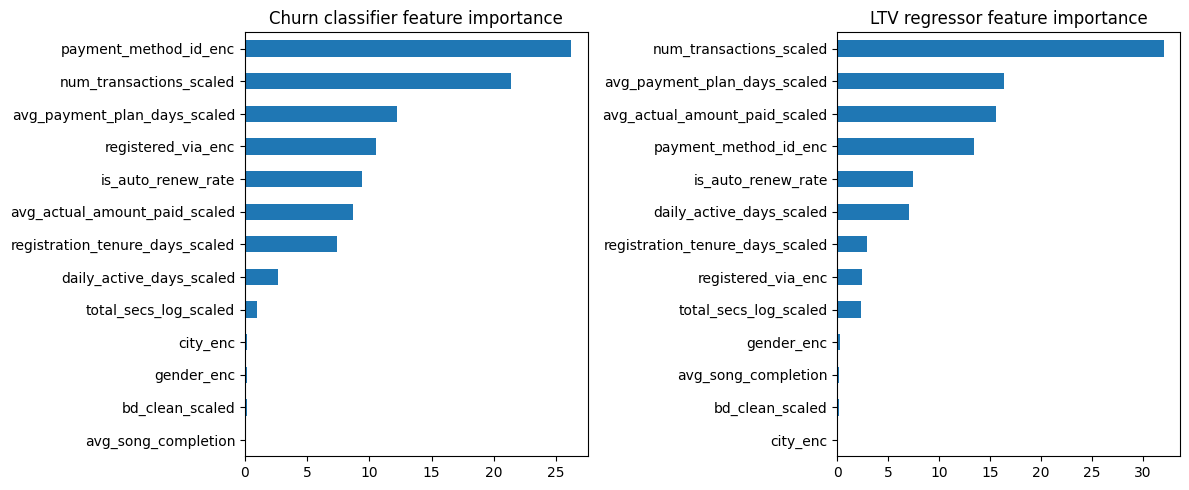

In [5]:
churn_importance = pd.Series(churn_model.get_feature_importance(), index=FEATURE_COLS).sort_values()
ltv_importance = pd.Series(ltv_model.get_feature_importance(), index=FEATURE_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
churn_importance.plot(kind="barh", ax=axes[0])
axes[0].set_title("Churn classifier feature importance")
ltv_importance.plot(kind="barh", ax=axes[1])
axes[1].set_title("LTV regressor feature importance")
fig.tight_layout()

## Cox Proportional Hazards via CatBoost (survival analysis)

CatBoost has a native `loss_function="Cox"` — gradient-boosted trees optimizing the Cox partial likelihood instead of a linear combination of covariates, giving a nonlinear/interaction-aware hazard model. Unlike the churn classifier above, this uses the **full censoring-inclusive paying population** (not `model_dataset`'s restricted population) — handling right-censored users properly is the entire point of a survival model, so restricting to only-confirmable cycles the way `02_Feature_Engineering.ipynb` does would defeat the purpose.

**Duration/event construction**: same per-user last-paid-cycle logic as `01_EDA.ipynb`'s Kaplan-Meier section — `duration_days` = first paid transaction to last-ever `membership_expire_date`, `event_churned = 1` if that expiry is confirmable (30+ days of runway before the 2017-02-28 data boundary), else censored. Also applies the same fix for the ~0.68% of transactions (mostly `is_cancel=1`) with a corrupted/reset `membership_expire_date` (excluded via an `expire_dt >= txn_dt` guard).

CatBoost's Cox loss expects the target as *signed* duration: positive for an observed event, negative for censored — same convention as XGBoost's `survival:cox`.

In [6]:
import duckdb

con = duckdb.connect()

con.execute(f"""
    create or replace temp table txn_cox as
    select *, strptime(cast(transaction_date as varchar), '%Y%m%d')::date as txn_dt,
           strptime(cast(membership_expire_date as varchar), '%Y%m%d')::date as expire_dt
    from '{os.path.join(PROCESSED_DIR, "transactions.parquet")}'
    where actual_amount_paid > 0
""")
# ref_date = each user's own last-ever paid cycle; min(txn_dt) is reliable, max(expire_dt)
# only considers rows with a plausible expiry (excludes the corrupted-reset ones)
con.execute("""
    create or replace temp table cox_ref as
    with valid_expiry as (
        select msno, expire_dt from txn_cox where expire_dt >= txn_dt
    )
    select t.msno, min(t.txn_dt) as start_dt, max(v.expire_dt) as ref_date,
           date_diff('day', min(t.txn_dt), max(v.expire_dt)) as duration_days,
           case when max(v.expire_dt) + interval 30 day <= date '2017-02-28' then 1 else 0 end as event_churned
    from txn_cox t
    join valid_expiry v using (msno)
    group by t.msno
""")

cox_query = f"""
    with txn_agg as (
        select t.msno, count(*) num_transactions,
               avg(t.payment_plan_days) avg_payment_plan_days,
               avg(t.actual_amount_paid) avg_actual_amount_paid,
               avg(t.is_auto_renew) is_auto_renew_rate
        from txn_cox t join cox_ref r using (msno)
        where t.txn_dt <= r.ref_date
        group by t.msno
    ),
    latest_txn as (
        select msno, payment_method_id from (
            select t.msno, t.payment_method_id,
                   row_number() over (partition by t.msno order by t.txn_dt desc) rn
            from txn_cox t join cox_ref r using (msno)
            where t.txn_dt <= r.ref_date
        ) where rn = 1
    ),
    logs_agg as (
        select l.msno,
               count(distinct l.log_dt) daily_active_days,
               sum(greatest(least(l.total_secs, 86400), 0)) total_secs_sum,
               sum(l.num_25) sum25, sum(l.num_50) sum50, sum(l.num_75) sum75,
               sum(l.num_985) sum985, sum(l.num_100) sum100
        from (select *, strptime(cast(date as varchar), '%Y%m%d')::date as log_dt
              from '{os.path.join(PROCESSED_DIR, "user_logs.parquet")}') l
        join cox_ref r using (msno)
        where l.log_dt >= r.ref_date - interval 29 day and l.log_dt <= r.ref_date
        group by l.msno
    )
    select r.msno, r.ref_date, r.duration_days, r.event_churned,
           m.city, m.bd, m.gender, m.registered_via, m.registration_init_time,
           coalesce(txn_agg.num_transactions, 0) num_transactions,
           txn_agg.avg_payment_plan_days, txn_agg.avg_actual_amount_paid,
           coalesce(txn_agg.is_auto_renew_rate, 0) is_auto_renew_rate,
           latest_txn.payment_method_id,
           coalesce(logs_agg.daily_active_days, 0) daily_active_days,
           coalesce(logs_agg.total_secs_sum, 0) total_secs_sum,
           coalesce(logs_agg.sum25,0) sum25, coalesce(logs_agg.sum50,0) sum50,
           coalesce(logs_agg.sum75,0) sum75, coalesce(logs_agg.sum985,0) sum985,
           coalesce(logs_agg.sum100,0) sum100
    from cox_ref r
    left join '{os.path.join(PROCESSED_DIR, "members.parquet")}' m using (msno)
    left join txn_agg using (msno)
    left join latest_txn using (msno)
    left join logs_agg using (msno)
"""
cox_df = con.execute(cox_query).df()
print(f"survival feature table: {cox_df.shape}")
print(f"event rate: {cox_df['event_churned'].mean():.3f}  (censored: {1 - cox_df['event_churned'].mean():.3f})")
assert (cox_df["duration_days"] >= 0).all()

survival feature table: (1734274, 21)
event rate: 0.375  (censored: 0.625)


In [7]:
from sklearn.model_selection import train_test_split

# Same derived features as 02_Feature_Engineering.ipynb, computed relative to each
# user's own ref_date instead of a shared cutoff.
reg_date = pd.to_datetime(
    cox_df["registration_init_time"].astype("Int64").astype(str), format="%Y%m%d", errors="coerce"
)
cox_df["registration_tenure_days"] = (pd.to_datetime(cox_df["ref_date"]) - reg_date).dt.days
cox_df["gender"] = cox_df["gender"].fillna("unknown")
cox_df["city"] = cox_df["city"].fillna(-1).astype(int)
cox_df["registered_via"] = cox_df["registered_via"].fillna(-1).astype(int)
cox_df["bd_clean"] = cox_df["bd"].where(cox_df["bd"].between(1, 100))

song_totals = cox_df[["sum25", "sum50", "sum75", "sum985", "sum100"]].sum(axis=1)
cox_df["avg_song_completion"] = (
    0.25 * cox_df["sum25"] + 0.50 * cox_df["sum50"] + 0.75 * cox_df["sum75"]
    + 0.985 * cox_df["sum985"] + 1.0 * cox_df["sum100"]
) / (song_totals + 1)
cox_df["total_secs_log"] = np.log1p(cox_df["total_secs_sum"])

COX_CAT_COLS = ["city", "gender", "registered_via", "payment_method_id"]
COX_NUM_COLS = [
    "bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid",
    "num_transactions", "total_secs_log", "daily_active_days", "is_auto_renew_rate", "avg_song_completion",
]

cox_train, cox_temp = train_test_split(cox_df, test_size=0.30, stratify=cox_df["event_churned"], random_state=42)
cox_val, cox_test = train_test_split(cox_temp, test_size=0.50, stratify=cox_temp["event_churned"], random_state=42)
cox_splits = {"train": cox_train, "val": cox_val, "test": cox_test}

# median imputation fit on train only (own splits -- this is a different population
# than model_dataset, so it gets its own imputation statistics, not 02's saved ones)
for col in ["bd_clean", "registration_tenure_days", "avg_payment_plan_days", "avg_actual_amount_paid"]:
    median = cox_train[col].median()
    for split in cox_splits.values():
        split[col] = split[col].fillna(median)

for name, split in cox_splits.items():
    print(f"{name:6s} n={len(split):>7,}  event_rate={split['event_churned'].mean():.4f}")

train  n=1,213,991  event_rate=0.3747
val    n=260,141  event_rate=0.3747
test   n=260,142  event_rate=0.3747


In [8]:
from lifelines.utils import concordance_index

# signed duration: positive = observed event, negative = censored (CatBoost/XGBoost Cox convention).
# +0.5 offset avoids the ambiguous case where duration_days == 0 (0.5% of users) --
# a bare 0 has no sign, so +0/-0 would collapse the event/censored distinction for them.
for split in cox_splits.values():
    signed_duration = split["duration_days"] + 0.5
    split["cox_target"] = np.where(split["event_churned"] == 1, signed_duration, -signed_duration)

cox_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Cox",
    cat_features=COX_CAT_COLS,
    early_stopping_rounds=50,
    random_seed=42,
    thread_count=4,
    verbose=100,
)
cox_model.fit(
    cox_train[COX_CAT_COLS + COX_NUM_COLS], cox_train["cox_target"],
    eval_set=(cox_val[COX_CAT_COLS + COX_NUM_COLS], cox_val["cox_target"]),
)
print(f"best iteration: {cox_model.get_best_iteration()}")

cox_results = {}
for name in ["val", "test"]:
    split = cox_splits[name]
    risk_score = cox_model.predict(split[COX_CAT_COLS + COX_NUM_COLS])
    # concordance_index expects higher score = longer survival, so negate the risk score
    c_index = concordance_index(split["duration_days"], -risk_score, split["event_churned"])
    cox_results[name] = {"concordance_index": c_index}
    print(f"{name}: concordance index = {c_index:.4f}")

with open(os.path.join(RESULTS_DIR, "cox_results.json"), "w") as f:
    json.dump(cox_results, f, indent=2)

0:	learn: -6147773.5415854	test: -1167245.7903865	best: -1167245.7903865 (0)	total: 628ms	remaining: 10m 27s


100:	learn: -5973108.2731717	test: -1129717.2275658	best: -1129717.2275658 (100)	total: 55.4s	remaining: 8m 12s


200:	learn: -5849328.7822155	test: -1103095.4637169	best: -1103095.4637169 (200)	total: 1m 49s	remaining: 7m 16s


300:	learn: -5759641.8055312	test: -1083820.2920638	best: -1083820.2920638 (300)	total: 2m 45s	remaining: 6m 24s


400:	learn: -5691928.2312175	test: -1069270.1489485	best: -1069270.1489485 (400)	total: 3m 41s	remaining: 5m 30s


...

800:	learn: -5532619.6742005	test: -1035056.0398938	best: -1035056.0398938 (800)	total: 7m 15s	remaining: 1m 48s


900:	learn: -5509086.1161268	test: -1030002.5784693	best: -1030002.5784693 (900)	total: 8m 7s	remaining: 53.6s


999:	learn: -5487799.7362892	test: -1025420.3609345	best: -1025420.3609345 (999)	total: 8m 58s	remaining: 0us

bestTest = -1025420.361
bestIteration = 999

best iteration: 999


val: concordance index = 0.9415


test: concordance index = 0.9413


Concordance index (test): 0.9413
(0.5 = random ranking, 1.0 = perfect ranking -- same intuition as AUC-ROC, but over survival time)


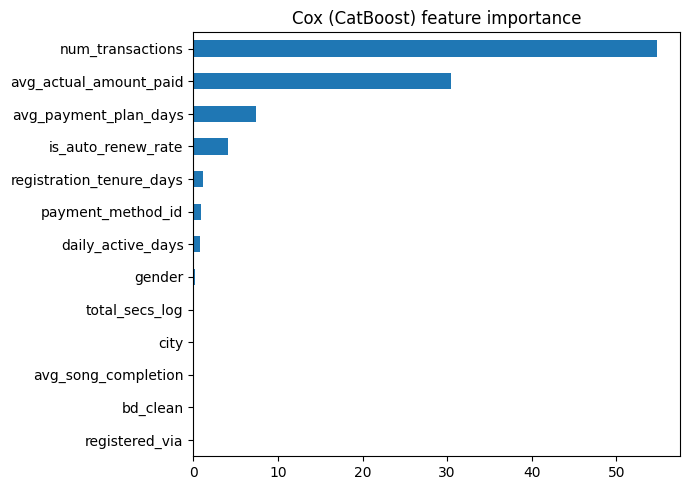

In [9]:
cox_importance = pd.Series(
    cox_model.get_feature_importance(), index=COX_CAT_COLS + COX_NUM_COLS
).sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
cox_importance.plot(kind="barh", ax=ax)
ax.set_title("Cox (CatBoost) feature importance")
fig.tight_layout()

print(f"Concordance index (test): {cox_results['test']['concordance_index']:.4f}")
print("(0.5 = random ranking, 1.0 = perfect ranking -- same intuition as AUC-ROC, but over survival time)")